# House Price Prediction - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the structure of the dataset, identify potential data quality issues, explore relationships between variables, and gather insights that will guide the preprocessing and modeling stages.

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

# Make plots a little larger
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Import Libraries

We begin by importing the libraries required for data manipulation and visualization.

In [27]:
house_data = pd.read_csv("../data/raw/dataset_2.csv")

house_data.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


## 2. Load the Dataset

The dataset contains information about residential properties, including numerical and categorical features that may influence the selling price. We load the data and inspect its structure before performing any analysis.

In [28]:
house_data.shape

(1124, 9)

In [29]:
house_data.columns

Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool', 'Price'],
      dtype='str')

## 3. Dataset Overview

Before analyzing the data, it is important to understand the number of observations, the available features, their data types, and whether any missing values are present.

In [30]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   str    
 4   Street_Type    1124 non-null   str    
 5   Furnishing     1091 non-null   str    
 6   Property_Type  1124 non-null   str    
 7   Has_Pool       1124 non-null   str    
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 79.2 KB


## 4. Summary Statistics

Summary statistics provide an overview of the numerical variables, including measures of central tendency and dispersion. This helps identify unusual values and understand the scale of each feature.

In [31]:
house_data.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1091.000000,1091.000000,1124.000000,1.124000e+03
mean,2237.479473,4.568286,2005.080071,6.082015e+05
std,731.097828,1.678155,11.708876,1.431958e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1834.022964,3.000000,1995.000000,5.161948e+05
50%,2201.545784,5.000000,2005.000000,6.025410e+05
75%,2576.139355,6.000000,2015.000000,6.895785e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


## 5. Missing Values Analysis

Machine learning models require complete data. We inspect each feature to determine whether missing values exist and assess the extent of the problem before deciding on an appropriate imputation strategy.

In [32]:
house_data.isnull().sum()

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

In [33]:
house_data.duplicated().sum()

np.int64(0)

## 6. Exploring the Target Variable

The target variable, **Price**, represents the value we aim to predict. Understanding its distribution helps determine whether transformations or specialized modeling techniques may be necessary.

In [34]:
house_data["Price"].describe()

count    1.124000e+03
mean     6.082015e+05
std      1.431958e+05
min      2.486400e+05
25%      5.161948e+05
50%      6.025410e+05
75%      6.895785e+05
max      2.071402e+06
Name: Price, dtype: float64

## 7. Relationship Between Numerical Features and Price

In this section, we explore how numerical features such as house area, number of rooms, and construction year relate to property prices.

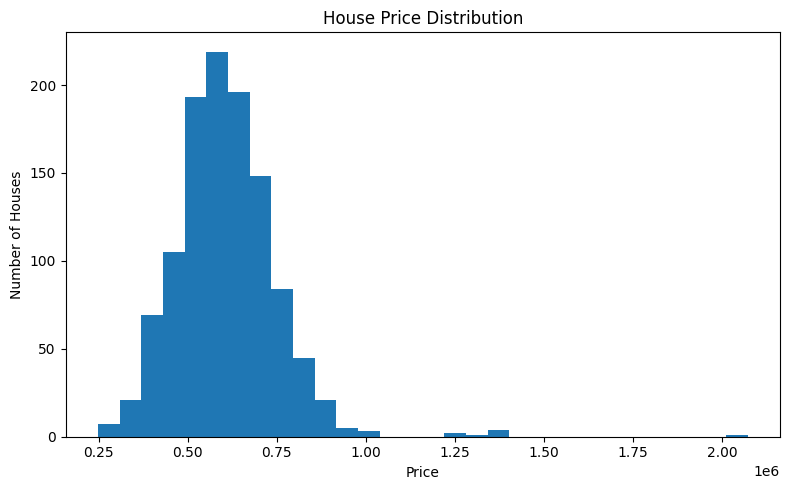

In [35]:
plt.figure(figsize=(8,5))

plt.hist(house_data["Price"], bins=30)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.tight_layout()

plt.show()

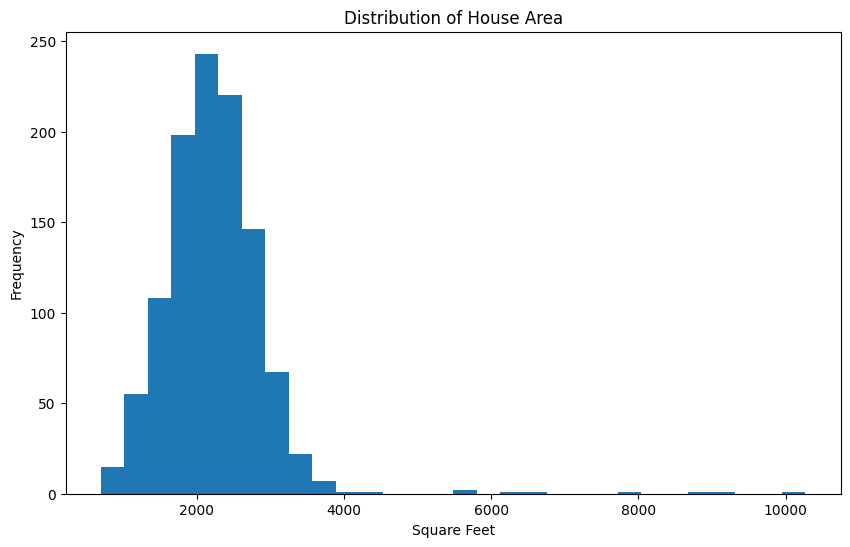

In [36]:
plt.hist(house_data["Area_SqFt"], bins=30)
plt.title("Distribution of House Area")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")
plt.show()

## 8. Analysis of Categorical Features

Categorical variables often have a significant impact on house prices. We compare average prices across different categories to identify potential patterns.

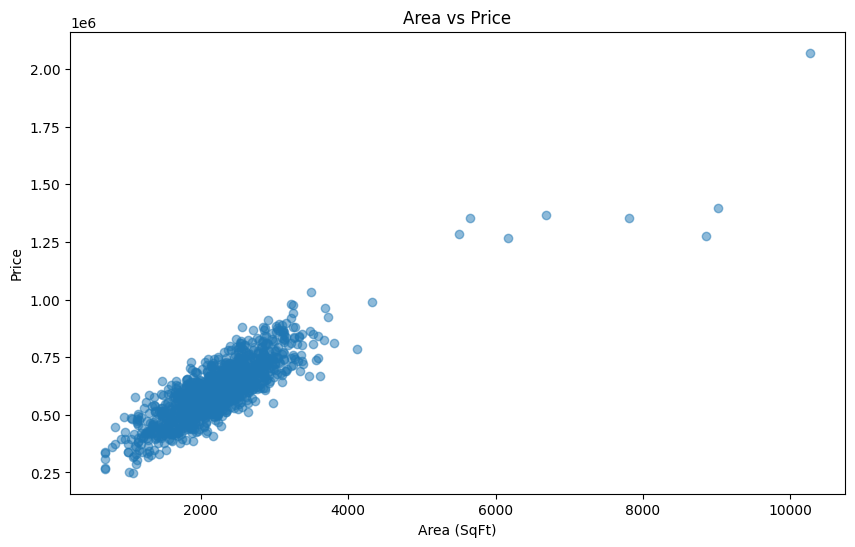

In [37]:
plt.scatter(
    house_data["Area_SqFt"],
    house_data["Price"],
    alpha=0.5
)

plt.xlabel("Area (SqFt)")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

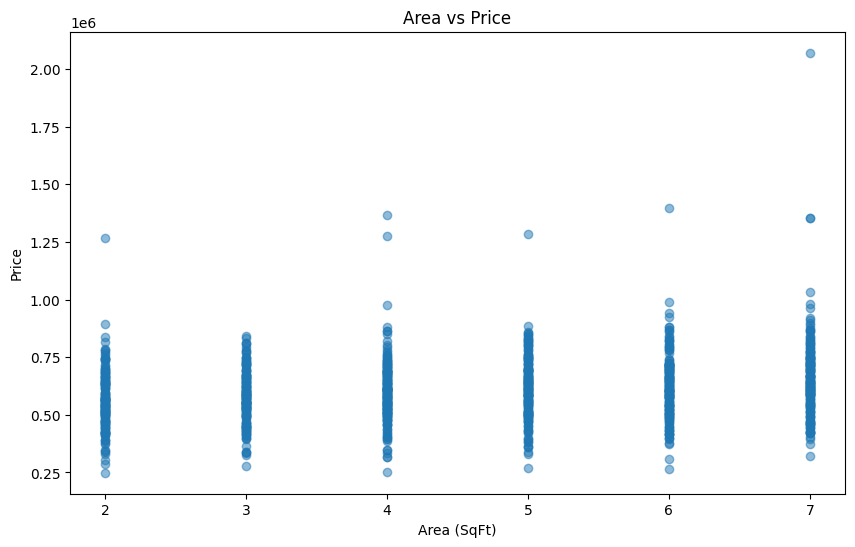

In [38]:
plt.scatter(
    house_data["Rooms"],
    house_data["Price"],
    alpha=0.5
)

plt.xlabel("Area (SqFt)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

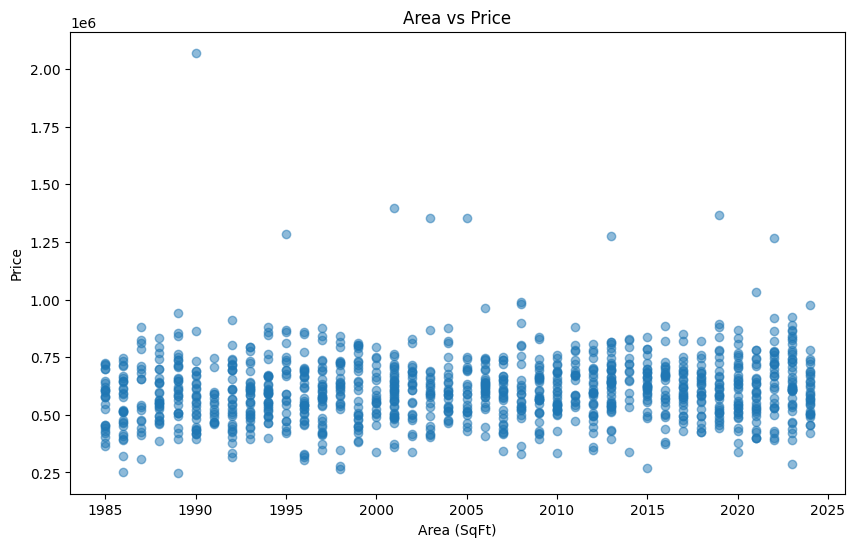

In [39]:
plt.scatter(
    house_data["Build_Year"],
    house_data["Price"],
    alpha=0.5
)

plt.xlabel("Area (SqFt)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [40]:
house_data.groupby("Location")["Price"].mean().sort_values()

Location
Prayagraj    567967.657904
Kanpur       570913.142857
Jaipur       580933.396165
Indore       595920.167579
Lucknow      606869.460841
Noida        622051.083333
Gurugram     655686.637795
Delhi        667981.325812
Name: Price, dtype: float64

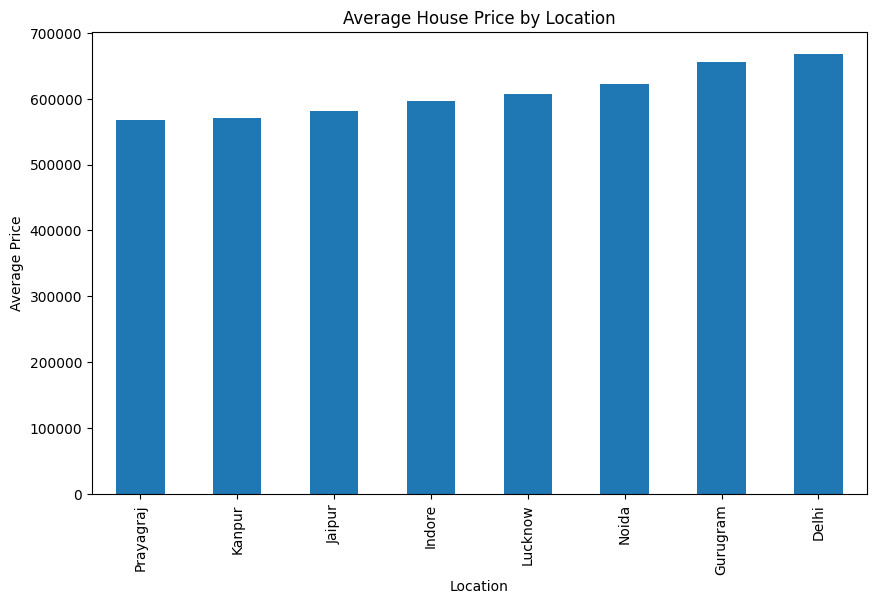

In [41]:
avg_price_location = (
    house_data
    .groupby("Location")["Price"]
    .mean()
    .sort_values()
)

avg_price_location.plot(kind="bar")

plt.title("Average House Price by Location")
plt.ylabel("Average Price")
plt.show()

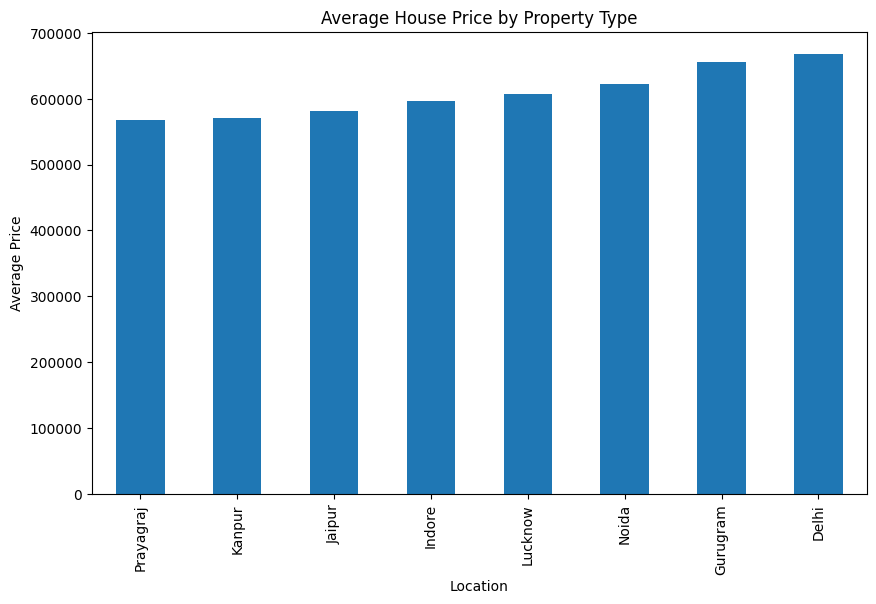

In [42]:
avg_price_property_type = (
    house_data
    .groupby("Property_Type")["Price"]
    .mean()
    .sort_values()
)

avg_price_location.plot(kind="bar")

plt.title("Average House Price by Property Type")
plt.ylabel("Average Price")
plt.show()

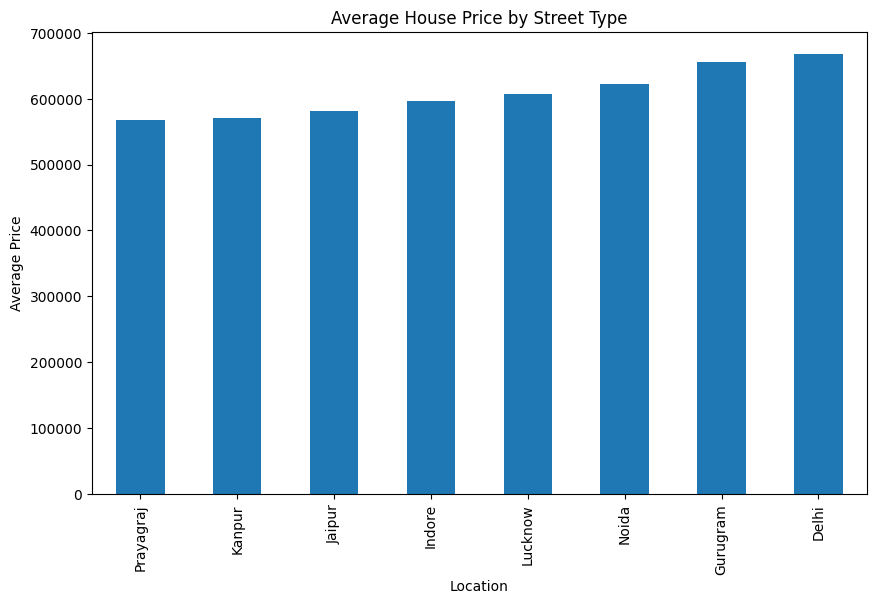

In [43]:
avg_price_street_type = (
    house_data
    .groupby("Street_Type")["Price"]
    .mean()
    .sort_values()
)

avg_price_location.plot(kind="bar")

plt.title("Average House Price by Street Type")
plt.ylabel("Average Price")
plt.show()

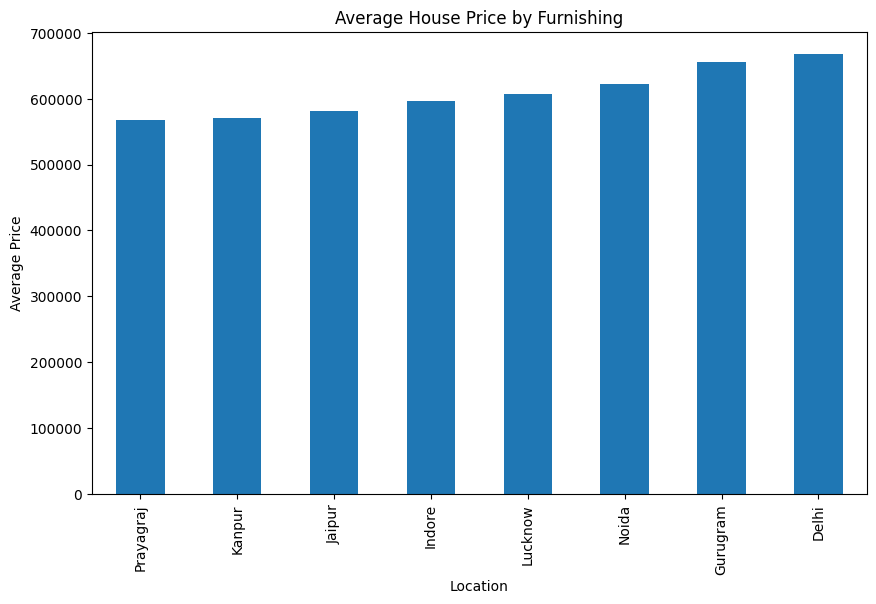

In [44]:
avg_price_furnishing = (
    house_data
    .groupby("Furnishing")["Price"]
    .mean()
    .sort_values()
)

avg_price_location.plot(kind="bar")

plt.title("Average House Price by Furnishing")
plt.ylabel("Average Price")
plt.show()

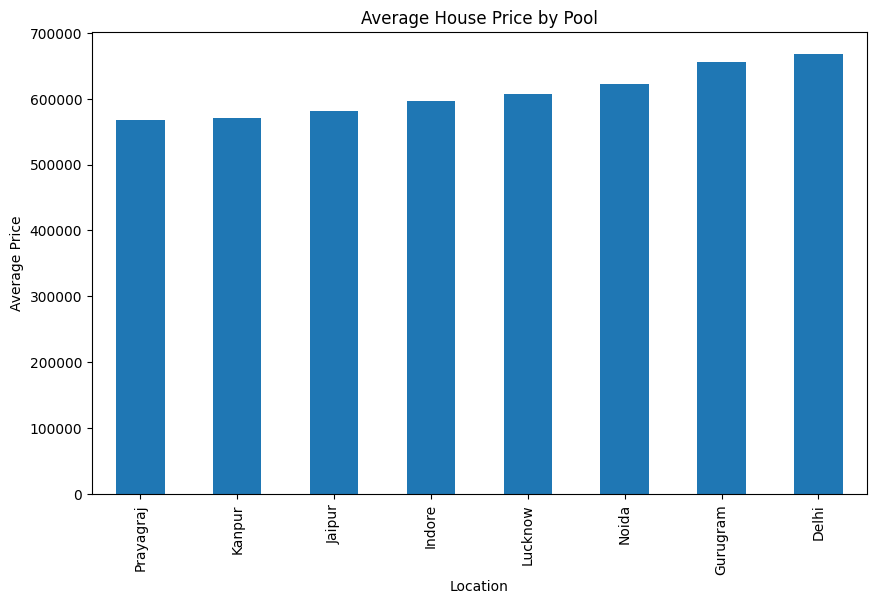

In [45]:
avg_price_has_pool = (
    house_data
    .groupby("Has_Pool")["Price"]
    .mean()
    .sort_values()
)

avg_price_location.plot(kind="bar")

plt.title("Average House Price by Pool")
plt.ylabel("Average Price")
plt.show()

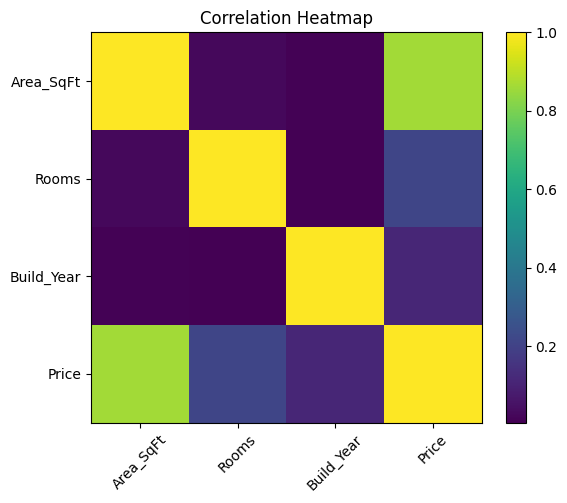

In [ ]:
numeric_data = house_data.select_dtypes(include=np.number)

correlation = numeric_data.corr()
correlation

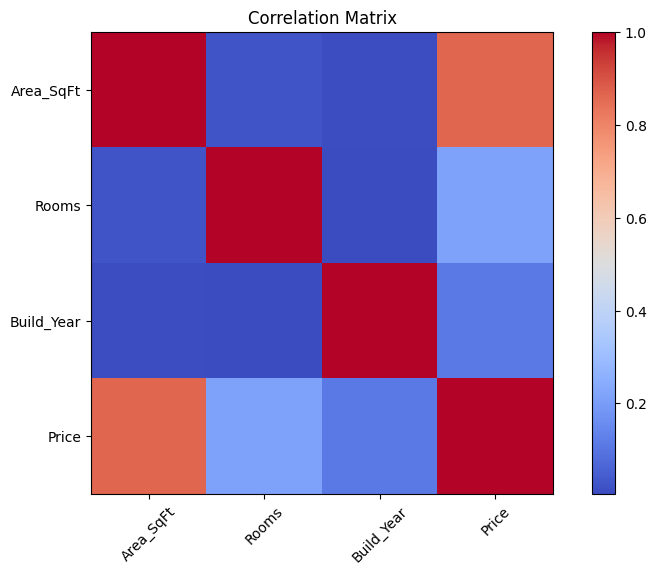

In [47]:
plt.imshow(correlation, cmap="coolwarm")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

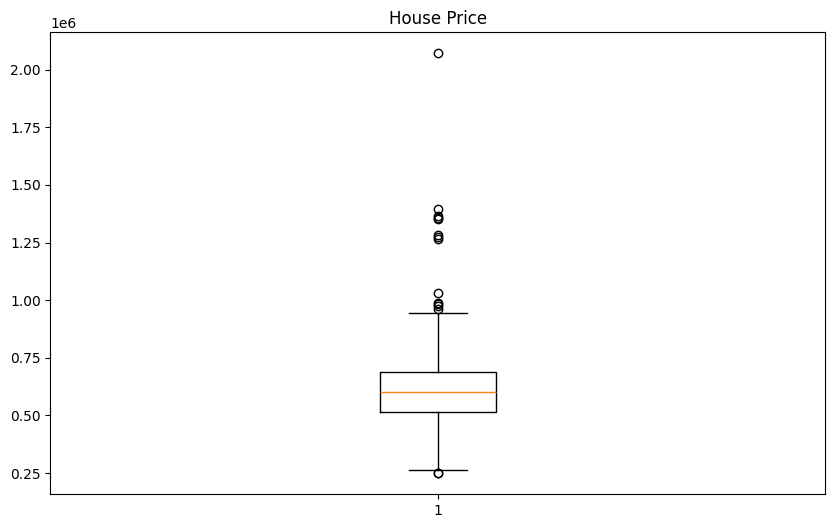

In [48]:
plt.boxplot(house_data["Price"])
plt.title("House Price")
plt.show()

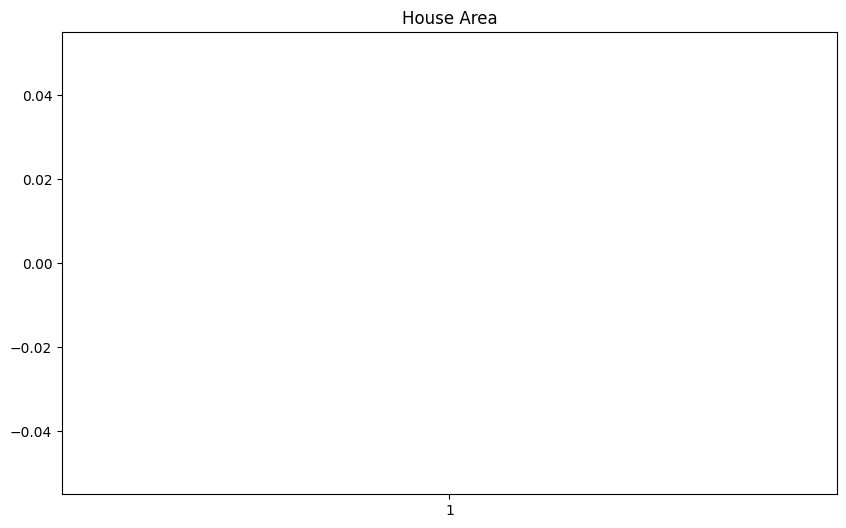

In [49]:
plt.boxplot(house_data["Area_SqFt"])
plt.title("House Area")
plt.show()

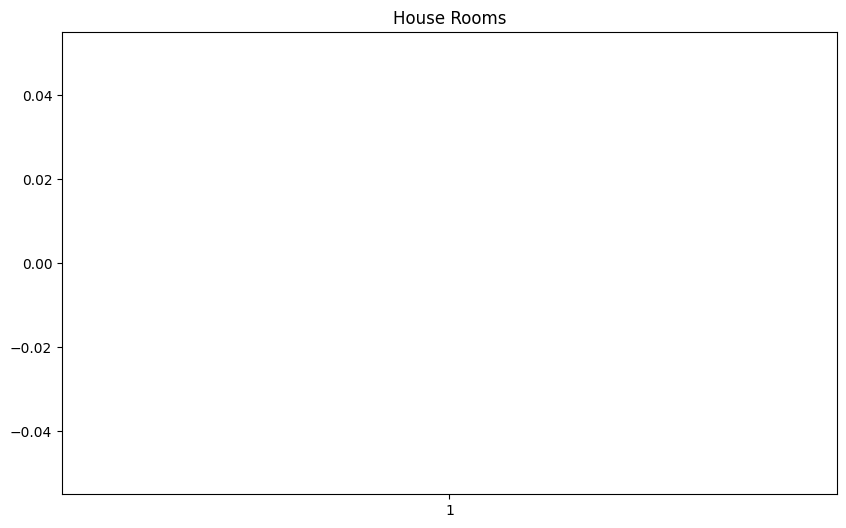

In [50]:
plt.boxplot(house_data["Rooms"])
plt.title("House Rooms")
plt.show()

# Conclusions

Based on the exploratory analysis, several observations can be made regarding the dataset quality and the factors influencing house prices.

## Initial Findings

- The dataset contains 1,124 observations.
- Three columns contain missing values:
  - Area_SqFt (33)
  - Rooms (33)
  - Furnishing (33)
- No duplicate rows were found.
- The target variable (Price) is slightly right-skewed.
- Area_SqFt shows a strong positive relationship with house prices.
- Houses with pools generally have higher prices.
- Several high-price outliers are present and will be evaluated during preprocessing.